# Figure3

In [33]:
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 
import pandas as pd 
eid = 'E116'

## Define heatmap function

In [15]:
import scipy
import seaborn as sns 
import matplotlib.pyplot as plt 
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib import rcParamsDefault
from typing import List, Union
import pandas as pd 
import numpy as np
from matplotlib.colors import Normalize, ListedColormap,LinearSegmentedColormap


def plot_heatmap(weight_matrix,axis=None,title=None, xlabel=None,ylabel="Locations",xticks = None,xticklabels=None,yticks=None,yticklabels=None,vmin=0,vmax=0.4):
    """
    Plots a clustered heatmap of the weights in a given subnetwork.

    Parameters:
    weight_matrix (DataFrame): A matrix containing the weights of edges in the subnetwork.
    output_path (str): The path where the output plot will be saved.

    Returns:
    None
    """
    
    # Define colors for the heatmap
    COLORS = ['#FFFDDF', "#7FCDBB", "#225EA8"]


    g = sns.heatmap(weight_matrix, cmap=mcolors.LinearSegmentedColormap.from_list("colormap", COLORS, N=100),ax=axis,vmin=vmin, vmax=vmax)
    if xticks:
        g.set_xticks(xticks)

    if yticks:
        g.set_yticks(yticks)


    # Set the font size and name for x-axis tick labels, and rotate them for better visibility
    # g.set_xticklabels(axis.get_xticklabels(), fontsize=6, rotation=50)

    # Set the font size and name for y-axis tick labels
    # g.set_yticklabels(axis.get_yticklabels(), rotation=360)

    # Customize tick parameters for the heatmap axes
    # g.tick_params(axis='both', which='major', length=0)

    # Adjust the colorbar tick parameters if collections exist
    if g.collections:
        g.collections[0].colorbar.ax.tick_params(labelsize=6, length=1)

    # Set labels for the x-axis and y-axis
    if xlabel:
        g.set_xlabel(xlabel)
    
    if ylabel:
        g.set_ylabel(ylabel)

    if xticklabels:
        g.set_xticklabels(xticklabels)

    if yticklabels:
        g.set_yticklabels(yticklabels,rotation=360)

    g.set_title(title)


In [16]:
rcParams.update(rcParamsDefault)
rcParams['pdf.fonttype'] = 42
sns.set(context = 'paper' , style='ticks' , 
    rc = {
        'figure.autolayout' : True,
        'font.sans-serif': ['Arial', 'Helvetica'],  # Specify Arial or Helvetica
        'axes.titlesize' : 8 ,
        'axes.titleweight' :'bold',
        'axes.titlesize': 10,  # Title font size
        
        'figure.titleweight' : 'bold' ,
        'figure.titlesize' : 8 ,
        
        'axes.labelsize' : 8 ,
        'axes.labelpad' : 2 ,
        # 'axes.labelweight' : 'bold' , 
        'axes.spines.top' : False,
        'axes.spines.right' : False,
        
        'xtick.labelsize' : 7 ,
        'ytick.labelsize' : 7 ,
        
        'legend.fontsize' : 8 ,
        'figure.figsize' : (16/2.54, 8/2.54) , 
        'figure.dpi': 300,      
        'figure.facecolor': 'w',
        'figure.edgecolor': 'k',   
        
        'xtick.direction' : 'out' ,
        'ytick.direction' : 'out' ,
        
        'xtick.major.size' : 2 ,
        'ytick.major.size' : 2 ,
        'xtick.minor.size': 2,  # X-axis minor tick length
        'ytick.minor.size': 2,  # Y-axis minor tick length

        'xtick.major.pad' : 2,
        'ytick.major.pad' : 2,
        
        'lines.linewidth' : 0.75  , 
        'axes.linewidth': 0.5,  # Axis line width
        'savefig.dpi': 300,  # Save resolution 
        'savefig.bbox': 'tight',  # Tight bounding box       
        }
    )

sns.set_palette("colorblind")


## Feature importance

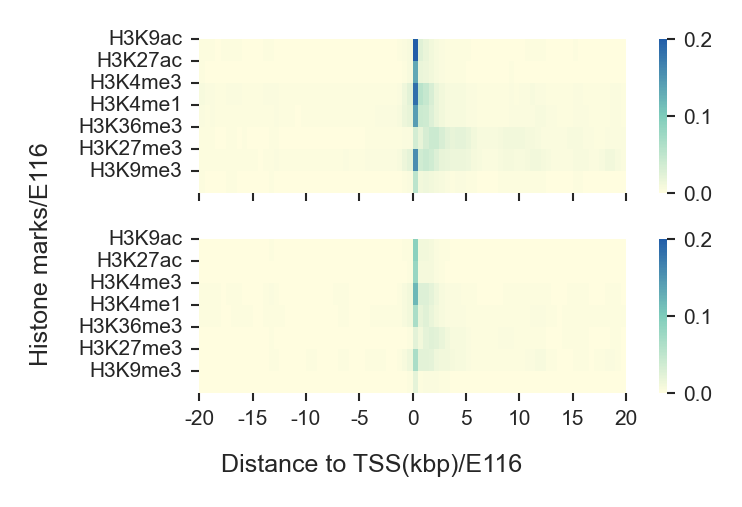

In [32]:
COLORS = ['#FFFDDF', "#7FCDBB", "#225EA8"]
MARKS = ["H3K4me1","H3K4me3","H3K9me3","H3K27me3","H3K36me3","H3K27ac","H3K9ac"]
yticks = [ 'H3K9ac', 'H3K27ac','H3K4me3','H3K4me1','H3K36me3','H3K27me3','H3K9me3']
idxes = [MARKS.index(mark) for mark in yticks]

with open(f'extra/datasets/results/{eid}_bf_deeplift_attributions.npy','rb') as f:
   attributions1 =  np.load(f)
   attributions1 = attributions1[idxes]

with open(f'extra/datasets/results/{eid}_bs_deeplift_attributions.npy','rb') as f:
   attributions2 =  np.load(f)
   attributions2 = attributions2[idxes]

fig, ax = plt.subplots(2, 1, constrained_layout=True, figsize=(6/2.54, 4/2.54))

xticks = [i for i in range(0, 81, 10)]
sns.heatmap(attributions1, cmap=mcolors.LinearSegmentedColormap.from_list("colormap", COLORS, N=100),
            ax=ax[0], vmin=0, vmax=0.2)
ax[0].tick_params(axis='both', labelsize=5, width=0.5)

sns.heatmap(attributions2, cmap=mcolors.LinearSegmentedColormap.from_list("colormap", COLORS, N=100),
            ax=ax[1], vmin=0, vmax=0.2)
ax[1].tick_params(axis='both', labelsize=5, width=0.5)

xticklabels = [int((i - 40) / 2) for i in range(0, 81, 10)]
ax[0].set_xticks(np.arange(0, 81, 10))
ax[1].set_xticks(np.arange(0, 81, 10), labels=xticklabels)

ax[0].set_yticks(np.arange(len(yticks)))
ax[0].set_yticklabels(yticks, rotation=360, fontsize=5)
ax[1].set_yticks(np.arange(len(yticks)))
ax[1].set_yticklabels(yticks, rotation=360, fontsize=5)

cbar1 = ax[0].collections[0].colorbar
cbar2 = ax[1].collections[0].colorbar

# 更改 colorbar 的字体大小
cbar1.ax.tick_params(width=0.5, labelsize=5)
cbar2.ax.tick_params(width=0.5, labelsize=5)

fig.supxlabel(f"Distance to TSS(kbp)/{eid}", fontsize=6)
fig.supylabel(f"Histone marks/{eid}", fontsize=6)

plt.show()


### BS BF locations importance

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


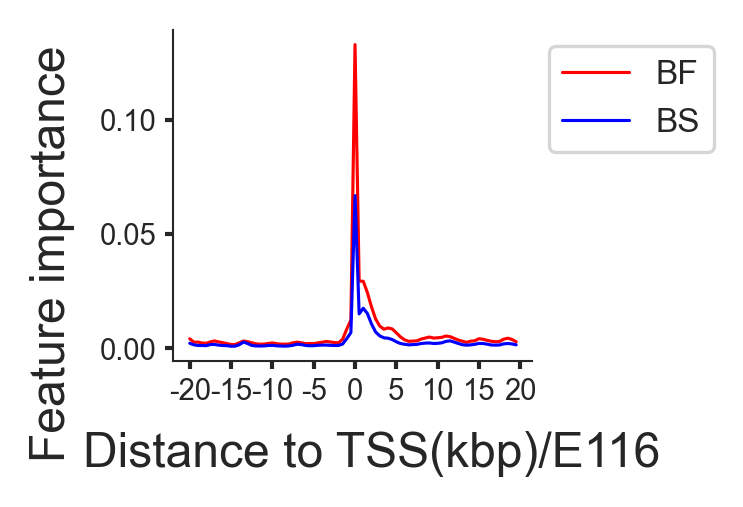

In [34]:
with open(f'extra/datasets/results/{eid}_bf_deeplift_distribution.npy','rb') as f:
   distribution1 =  np.load(f)

with open(f'extra/datasets/results/{eid}_bs_deeplift_distribution.npy','rb') as f:
   distribution2 =  np.load(f)

fig, ax =plt.subplots(1,1,constrained_layout=True,figsize=(6/2.54, 4/2.54))

g1 = sns.lineplot(distribution1, color='red', label = 'BF')
g2 = sns.lineplot(distribution2, color='blue', label = 'BS')
# Adjust layout to ensure everything fits
g1.legend(loc='upper left', bbox_to_anchor=(1, 1))
g1.set_xticks([i for i in range(0,81,10)])

xticklabels = [int((i-40)/2) for i in range(0,81,10)]
g1.set_xticklabels(xticklabels)
g2.set_xticklabels(xticklabels)

fig.supxlabel(f"Distance to TSS(kbp)/{eid}")
fig.supylabel(f"Feature importance")

plt.savefig('extra/datasets/figures/Figure3.a.eps', format='eps', bbox_inches='tight')
plt.show()

### Correlation between HMs

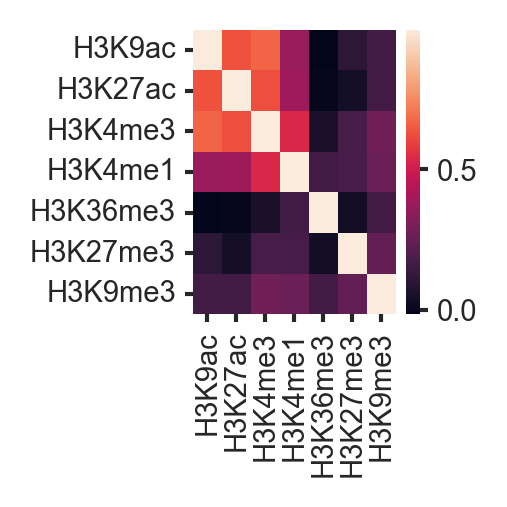

In [29]:
# correlation
correlation = np.loadtxt(f'extra/datasets/results/{eid}_hm_correlation.csv',delimiter=",")
# 选择第 0 个样本的行间相关性矩阵
yticks = [ 'H3K9ac', 'H3K27ac','H3K4me3','H3K4me1','H3K36me3','H3K27me3','H3K9me3']

fig, ax =plt.subplots(1,1,constrained_layout=True,figsize=(4/2.54, 4/2.54))
ax = sns.heatmap(correlation)
ax.set_xticklabels(yticks,rotation=90)
ax.set_yticklabels(yticks,rotation=360)
plt.show()


In [27]:
correlation.shape 

(7, 7)

### BS pred score marks strength （All BS）

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


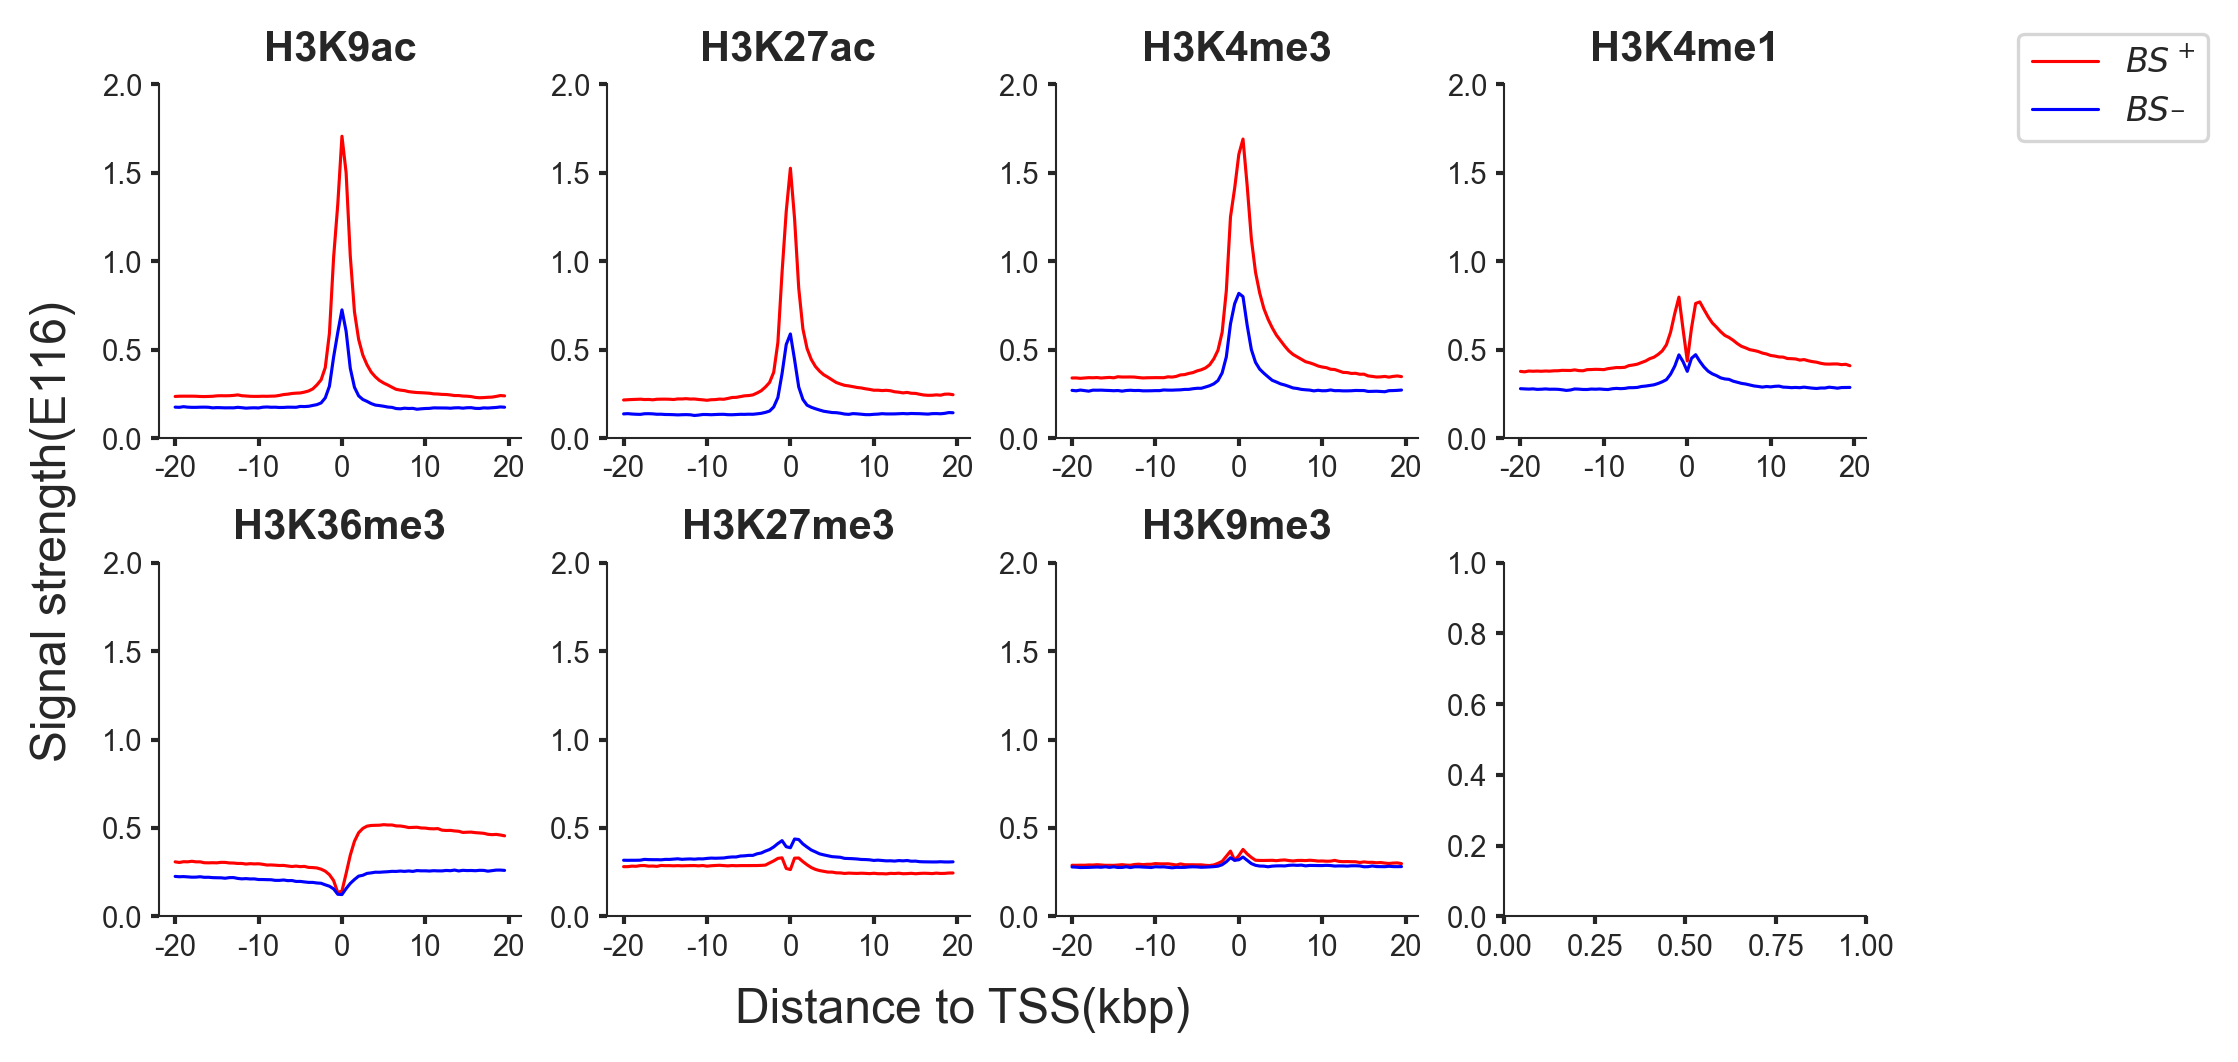

In [30]:
high_marks = np.load(f"extra/datasets/results/{eid}_bs_highmarks.npy")
low_marks = np.load(f"extra/datasets/results/{eid}_bs_lowmarks.npy")
MARKS = ['H3K4me1', 'H3K4me3', 'H3K9me3', 'H3K27me3', 'H3K36me3', 'H3K27ac', 'H3K9ac']
yticks = [ 'H3K9ac', 'H3K27ac','H3K4me3','H3K4me1','H3K36me3','H3K27me3','H3K9me3']

fig, ax = plt.subplots(2, 4, constrained_layout=True, figsize=(16/2.54, 8.7/2.54))

# Loop through the plots and plot the data without labels for legends
for idx, mark in enumerate(yticks):
    _idx = MARKS.index(mark)
    # Plot the data without 'label' argument to avoid legends in subplots
    sns.lineplot(high_marks[_idx], color='red',  ax=ax[idx // 4, idx % 4])
    sns.lineplot(low_marks[_idx], color='blue',  ax=ax[idx // 4, idx % 4])
    
    # Set the y-axis ticks
    ax[idx // 4, idx % 4].set_yticks([i * 0.1 for i in range(0, 21, 5)])
    ax[idx // 4, idx % 4].set_xticks([i for i in range(0, 81, 20)],labels=[int((i-40)/2) for i in range(0, 81, 20)])

    # Set the title for each subplot
    ax[idx // 4, idx % 4].set_title(mark)

    # Set the xlabel for each subplot

# Create a single shared legend
# Handles are explicitly created using the line objects from the first plot
handles, labels = ax[0, 0].get_lines(), ['$BS^+$', '$BS^\_$']

# Add a legend at the upper right of the 3rd subplot (1st row, 3rd column)
fig.legend(handles, labels, loc='upper left', bbox_to_anchor=(1.05, 1.0))
fig.supxlabel("Distance to TSS(kbp)")
fig.supylabel(f"Signal strength({eid})")
fig.align_ylabels()
# Adjust layout to ensure everything fits
plt.savefig('extra/datasets/figures/Figure3.e_1.eps', format='eps', bbox_inches='tight')

plt.show()


### BF pred score marks strength （All BF）

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


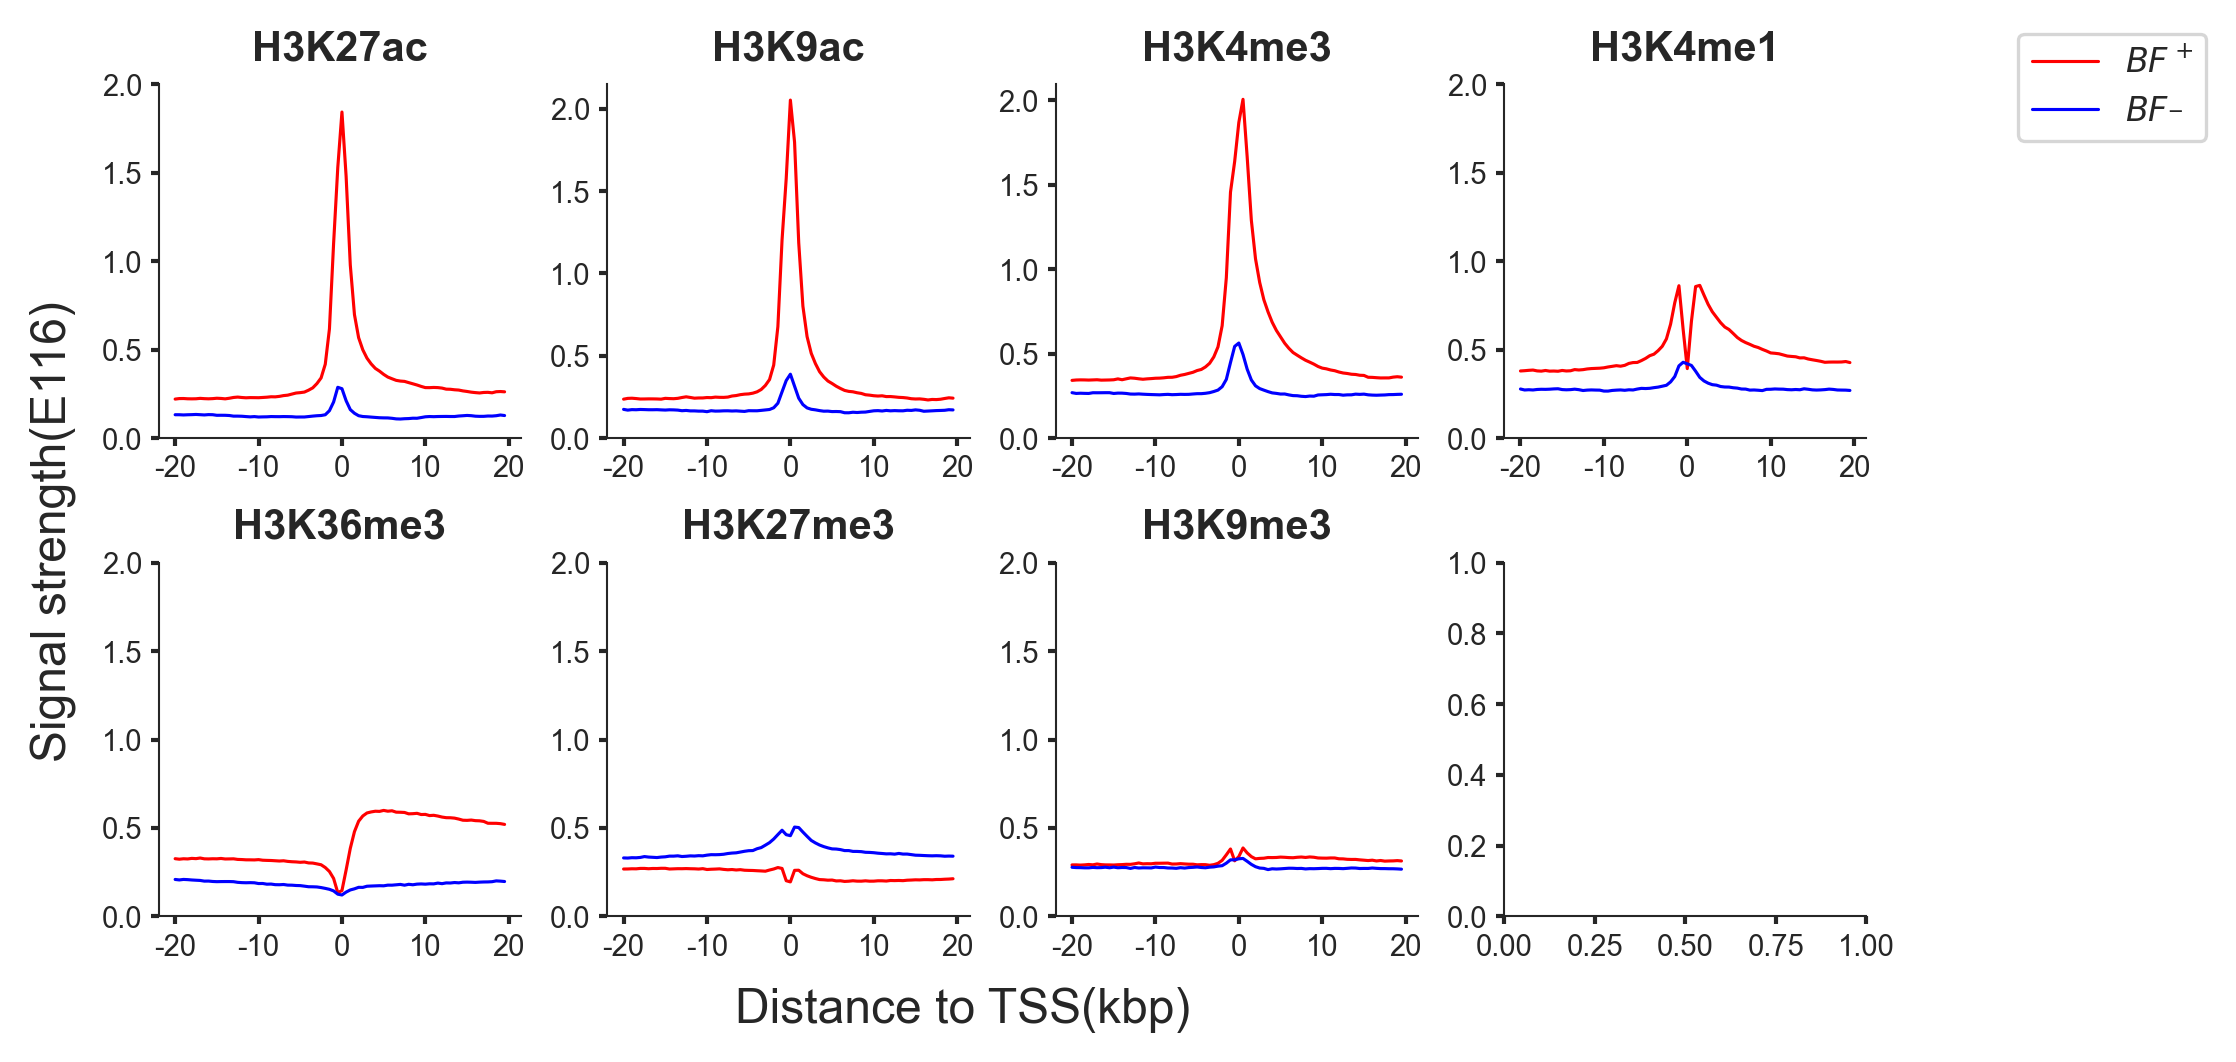

In [31]:
high_marks = np.load(f"extra/datasets/results/{eid}_bf_highmarks.npy")
low_marks = np.load(f"extra/datasets/results/{eid}_bf_lowmarks.npy")
MARKS = ['H3K4me1', 'H3K4me3', 'H3K9me3', 'H3K27me3', 'H3K36me3', 'H3K27ac', 'H3K9ac']
yticks = [ 'H3K27ac', 'H3K9ac','H3K4me3','H3K4me1','H3K36me3','H3K27me3','H3K9me3']

fig, ax = plt.subplots(2, 4, constrained_layout=True, figsize=(16/2.54, 8.7/2.54))

# Loop through the plots and plot the data without labels for legends
for idx, mark in enumerate(yticks):
    _idx = MARKS.index(mark)
    # Plot the data without 'label' argument to avoid legends in subplots
    sns.lineplot(high_marks[_idx], color='red',  ax=ax[idx // 4, idx % 4])
    sns.lineplot(low_marks[_idx], color='blue',  ax=ax[idx // 4, idx % 4])
    
    # Set the y-axis ticks
    ax[idx // 4, idx % 4].set_yticks([i * 0.1 for i in range(0, 21, 5)])
    ax[idx // 4, idx % 4].set_xticks([i for i in range(0, 81, 20)],labels=[int((i-40)/2) for i in range(0, 81, 20)])

    # Set the title for each subplot
    ax[idx // 4, idx % 4].set_title(mark)

    # Set the xlabel for each subplot

# Create a single shared legend
# Handles are explicitly created using the line objects from the first plot
handles, labels = ax[0, 0].get_lines(), ['$BF^+$', '$BF^\_$']

# Add a legend at the upper right of the 3rd subplot (1st row, 3rd column)
fig.legend(handles, labels, loc='upper left', bbox_to_anchor=(1.05, 1.0))
fig.supxlabel("Distance to TSS(kbp)")
fig.supylabel(f"Signal strength({eid})")
fig.align_ylabels()
# Adjust layout to ensure everything fits
plt.savefig('extra/datasets/figures/Figure3.f_1.eps', format='eps', bbox_inches='tight')

plt.show()

# One-feature ablation

In [3]:
data = pd.read_csv('extra/datasets/results/one_feature_indicators.csv')
data

,eid,keep_mark,fold,auc,target
0,E116,H3K4me1,0,77.562077,bs_label
1,E116,H3K4me1,0,91.267089,bf_label
2,E116,H3K4me1,1,77.331183,bs_label
3,E116,H3K4me1,1,92.768745,bf_label
4,E116,H3K4me1,2,79.249251,bs_label
...,...,...,...,...,...
163,E003,H3K9ac,1,92.243379,bf_label
164,E003,H3K9ac,2,73.775451,bs_label
165,E003,H3K9ac,2,93.085816,bf_label
166,E003,H3K9ac,3,71.110264,bs_label


## BS one-feature ablation

/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_96409/150281968.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right',fontdict={'size':8})  # ha参数用于设置水平对齐方式
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


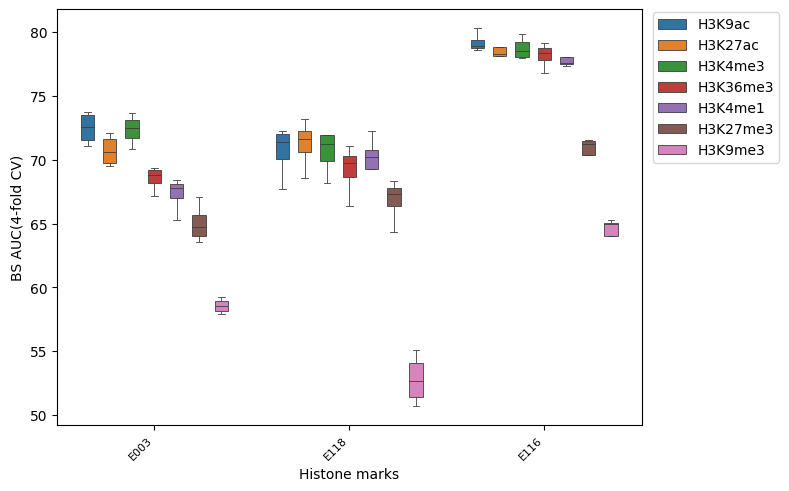

In [4]:
# 设置为 colorblind 调色板
# sns.set_palette("colorblind")
# sns.set_context("paper") 

df = data[data['target'] == 'bs_label']
# fig=plt.figure(figsize=(3.6,3.6) , dpi= 300, facecolor='w', edgecolor='k')
# fig.tight_layout(pad = 1)
fig, ax = plt.subplots(1,1,constrained_layout=True)
hue_order = pd.Index(["H3K9ac","H3K27ac","H3K4me3","H3K36me3","H3K4me1","H3K27me3","H3K9me3"],name='marks')
order = pd.Index(["E003","E118","E116"],name='marks')
ax = sns.boxplot(data=df,y='auc',x='eid',hue='keep_mark',gap=0.4,width=0.8,fliersize=0,order=order,hue_order=hue_order,linewidth=0.6)
plt.ylabel(f'BS AUC(4-fold CV)')
plt.xlabel(f'Histone marks')
# ax.set_ylim(top=4)
ax.legend().remove()
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right',fontdict={'size':8})  # ha参数用于设置水平对齐方式
fig.legend(loc='upper left', bbox_to_anchor=(1, 1))  # Moves the legend outside the 
plt.savefig('extra/datasets/figures/Figure3.c.eps', format='eps', bbox_inches='tight')
plt.show()

## BF one-feature ablation

/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_96409/3049568492.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right',fontdict={'size':8})  # ha参数用于设置水平对齐方式
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


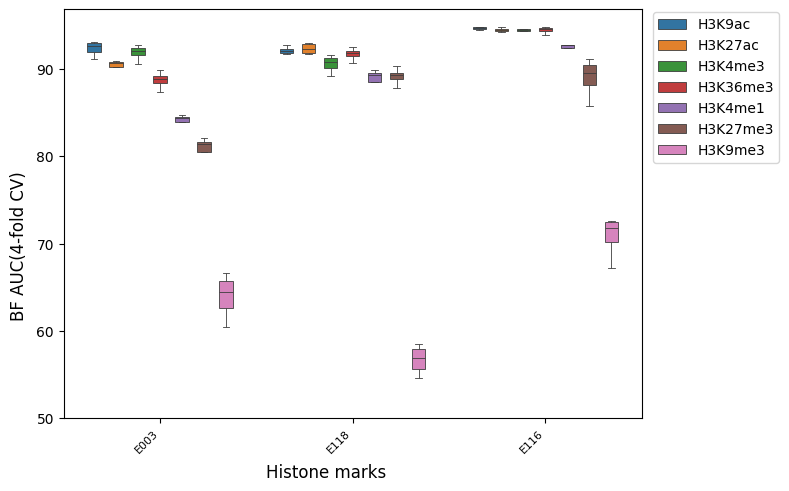

In [5]:
df = data[data['target'] == 'bf_label']
# fig=plt.figure(figsize=(3.6,3.6) , dpi= 300, facecolor='w', edgecolor='k')
# fig.tight_layout(pad = 1)
fig, ax = plt.subplots(1,1,constrained_layout=True)
hue_order = pd.Index(["H3K9ac","H3K27ac","H3K4me3","H3K36me3","H3K4me1","H3K27me3","H3K9me3"],name='marks')
order = pd.Index(["E003","E118","E116"],name='marks')
ax = sns.boxplot(data=df,y='auc',x='eid',hue='keep_mark',gap=0.4,width=0.8,fliersize=0,order=order,hue_order=hue_order,linewidth=0.6)
ax.set_xlabel('')
ax.set_ylabel('')

fig.supylabel(f'BF AUC(4-fold CV)')
fig.supxlabel(f'Histone marks')
# ax.set_ylim(top=4)
ax.legend().remove()
ax.set_ylim(bottom=50)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right',fontdict={'size':8})  # ha参数用于设置水平对齐方式
fig.legend(loc='upper left', bbox_to_anchor=(1, 1))  # Moves the legend outside the 
plt.savefig('extra/datasets/figures/Figure3.d.eps', format='eps', bbox_inches='tight')
plt.show()